<a href="https://colab.research.google.com/github/jarzolads/ML-BUAP-IBERO/blob/main/02_regresion_solubilidad_smiles_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

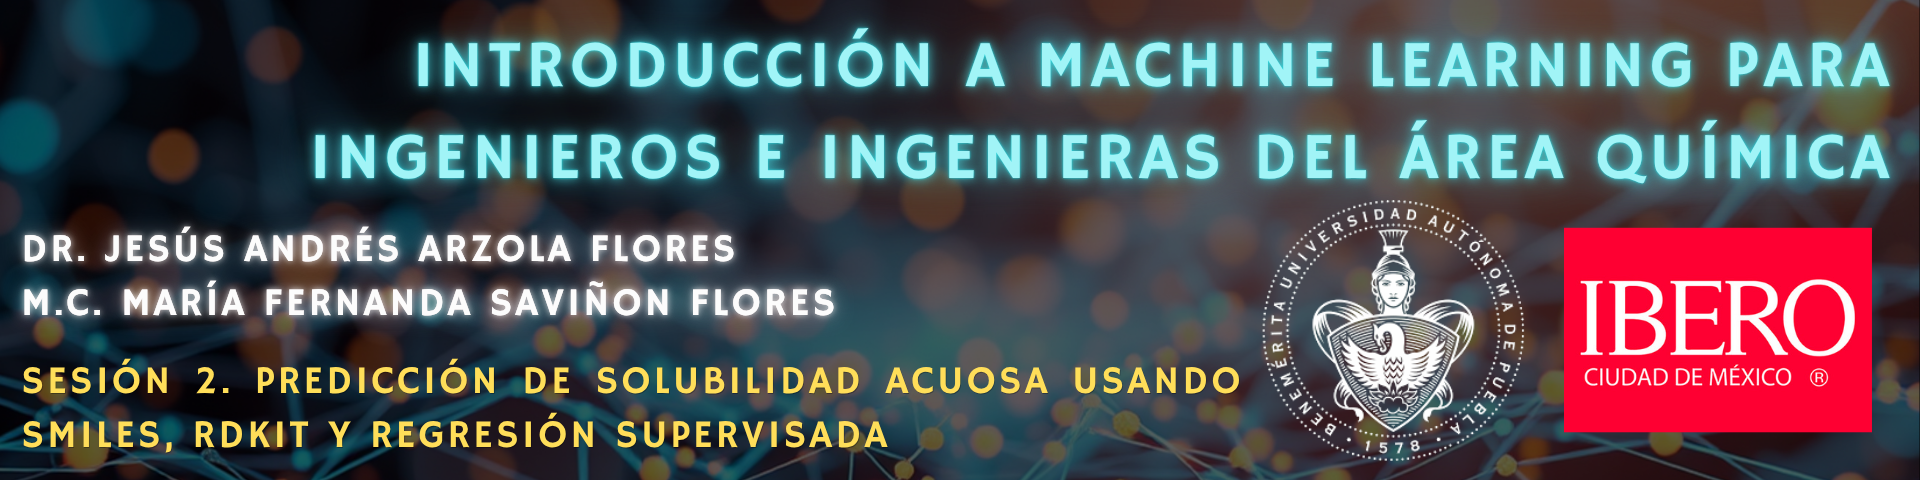

# Sesión 2. Predicción de solubilidad acuosa usando SMILES, RDKit y regresión supervisada

**Curso:** Machine Learning introductorio para estudiantes de licenciatura del área química  
**Metodología:** Aprendizaje Basado en Casos  
**Duración de la sesión:** 2 horas  
**Entorno de trabajo:** Google Colab

---

## Instrucción inicial

Antes de comenzar, guarda una copia de este notebook en tu Google Drive:

**Archivo → Guardar una copia en Drive**

Trabajarás sobre tu propia copia del archivo.


## 1. Contexto del caso

Un laboratorio del área química desea estimar la **solubilidad acuosa** de compuestos orgánicos antes de realizar ensayos experimentales. La solubilidad acuosa es una propiedad fundamental porque indica qué cantidad de una sustancia puede disolverse en agua bajo condiciones definidas de temperatura y presión. Esta propiedad es relevante en ingeniería química, ambiental, farmacéutica, alimentos, diseño de solventes, tratamiento de contaminantes, formulación de productos y evaluación preliminar del comportamiento de compuestos en sistemas acuosos.

En la práctica, determinar experimentalmente la solubilidad de cada compuesto puede requerir tiempo, reactivos, equipo especializado, personal capacitado y generación de residuos. Además, cuando se trabaja con muchas moléculas candidatas, medir todas experimentalmente puede ser costoso e ineficiente. Por ello, los modelos predictivos basados en datos pueden servir como una herramienta preliminar para **priorizar compuestos**, **reducir experimentación innecesaria**, **disminuir consumo de reactivos**, **ahorrar tiempo de laboratorio** y **orientar la toma de decisiones** antes de realizar pruebas confirmatorias.

En esta sesión se usará un conjunto de datos real conocido como **Delaney/ESOL**, que contiene compuestos orgánicos representados mediante códigos **SMILES** y valores experimentales de solubilidad acuosa expresados como logaritmo de la concentración molar. A partir de los SMILES se calcularán **descriptores moleculares** con **RDKit**, y esos descriptores se usarán como variables predictoras para entrenar modelos de regresión.

Este caso corresponde a un enfoque **QSPR** (*Quantitative Structure–Property Relationship*), ya que se busca relacionar cuantitativamente la estructura molecular con una propiedad fisicoquímica: la solubilidad acuosa.

**Idea central del caso:**

**estructura molecular → SMILES → RDKit → descriptores moleculares → modelo de regresión → predicción de solubilidad**


## 2. Pregunta detonadora

**¿Podemos predecir la solubilidad acuosa de un compuesto químico a partir de su estructura molecular para reducir tiempo, costo y experimentación innecesaria?**

Esta pregunta permite conectar conceptos de estructura molecular, datos químicos, descriptores moleculares, modelos QSPR y evaluación de modelos de Machine Learning.


## 3. Objetivo de aprendizaje

Al finalizar esta sesión, el participante será capaz de:

- Definir solubilidad acuosa y explicar su importancia en el área química.
- Comprender qué es una representación molecular SMILES.
- Reconocer la utilidad de RDKit para calcular descriptores moleculares.
- Construir un conjunto de datos a partir de estructuras químicas.
- Diferenciar variables predictoras y variable objetivo.
- Dividir datos en entrenamiento y prueba.
- Entrenar modelos básicos de regresión para predecir una propiedad fisicoquímica.
- Evaluar el desempeño mediante R², MAE y RMSE.
- Interpretar los resultados desde una perspectiva química, ambiental y técnica.
- Reflexionar sobre el uso responsable de modelos predictivos para reducir experimentación innecesaria.


## 4. Conceptos necesarios

### 4.1 Solubilidad acuosa

La **solubilidad acuosa** es la cantidad máxima de una sustancia que puede disolverse en agua, bajo condiciones específicas de temperatura y presión, hasta formar una solución homogénea en equilibrio. En compuestos orgánicos, esta propiedad depende de la estructura molecular, polaridad, tamaño, capacidad de formar puentes de hidrógeno, ionización, flexibilidad molecular e interacciones soluto–solvente.

En este conjunto de datos, la solubilidad se expresa como:

$$log S$$

Donde $S$ es la solubilidad molar en agua, normalmente expresada en $mol/L$. La transformación logarítmica se usa porque la solubilidad de diferentes compuestos puede variar en varios órdenes de magnitud.

---

### 4.2 ¿Qué es SMILES?

**SMILES** significa *Simplified Molecular Input Line Entry System*. Es una notación lineal que permite representar moléculas como cadenas de texto. Un SMILES codifica átomos, enlaces, ramificaciones, anillos, aromaticidad, cargas y, si se requiere, estereoquímica.

Ejemplos básicos:

| Molécula | SMILES | Lectura química básica |
|---|---|---|
| Metano | `C` | Un carbono saturado |
| Etano | `CC` | Dos carbonos unidos por enlace simple |
| Etanol | `CCO` | Cadena C–C–O |
| Dióxido de carbono | `O=C=O` | Dos dobles enlaces C=O |
| Benceno | `c1ccccc1` | Anillo aromático de seis carbonos |
| Ácido acético | `CC(=O)O` | Grupo carboxilo unido a metilo |
| Cloruro de sodio | `[Na+].[Cl-]` | Iones separados no enlazados |

---

### 4.3 Caracteres comunes en SMILES

| Símbolo | Significado | Ejemplo |
|---|---|---|
| Letras mayúsculas | Átomos alifáticos | `C`, `N`, `O`, `Cl` |
| Letras minúsculas | Átomos aromáticos | `c1ccccc1` |
| `-` | Enlace simple explícito, casi siempre omitido | `C-C` equivale a `CC` |
| `=` | Enlace doble | `C=O` |
| `#` | Enlace triple | `C#N` |
| `()` | Ramificación | `CC(=O)O` |
| Números | Cierre de anillos | `C1CCCCC1` |
| `.` | Fragmentos no enlazados | `[Na+].[Cl-]` |
| `[]` | Átomos con detalles especiales: carga, isótopo, hidrógenos explícitos | `[NH4+]`, `[O-]` |
| `/` y `\` | Estereoquímica en dobles enlaces | `F/C=C/F` |

---

### 4.4 ¿Cómo obtener el SMILES de una molécula?

Existen varias formas de obtener un SMILES:

1. **Desde una base de datos química:** PubChem, ChemSpider, NIST Chemistry WebBook, ChEMBL, etc.
2. **Desde un editor molecular:** dibujando la estructura y exportando el SMILES.
3. **Desde software químico o quimioinformático:** RDKit, Open Babel, CDK, Avogadro, MarvinSketch.
4. **Escribiéndolo manualmente:** para moléculas sencillas.

#### Procedimiento general usando PubChem

1. Buscar la molécula por nombre, por ejemplo: “ethanol”.
2. Entrar al registro del compuesto.
3. Localizar la sección de identificadores químicos.
4. Copiar el **Canonical SMILES** o **Isomeric SMILES**.
5. Verificar que corresponda a la molécula correcta.

#### Diferencia entre Canonical SMILES e Isomeric SMILES

- **Canonical SMILES:** representación única generada por un algoritmo para una molécula dada. Es útil para identificación y comparación.
- **Isomeric SMILES:** incluye información de estereoquímica o isomería cuando aplica.

---

### 4.5 Ejemplos paso a paso para escribir SMILES

#### Ejemplo 1: etanol

Estructura: CH₃–CH₂–OH

1. Primer carbono: `C`
2. Segundo carbono unido por enlace simple: `CC`
3. Oxígeno del grupo alcohol: `CCO`

SMILES: `CCO`

#### Ejemplo 2: acetona

Estructura: CH₃–C(=O)–CH₃

1. Cadena de tres carbonos: `CCC`
2. El carbono central tiene un oxígeno con doble enlace.
3. Se agrega la ramificación: `CC(=O)C`

SMILES: `CC(=O)C`

#### Ejemplo 3: ácido acético

Estructura: CH₃–C(=O)–OH

1. Grupo metilo: `C`
2. Carbonilo: `C(=O)`
3. Hidroxilo del ácido: `O`

SMILES: `CC(=O)O`

#### Ejemplo 4: benceno

El benceno es un anillo aromático de seis carbonos.

1. Carbonos aromáticos se escriben con `c` minúscula.
2. Los números indican cierre del anillo.

SMILES: `c1ccccc1`

---

### 4.6 ¿Qué son QSAR y QSPR?

**QSAR** significa *Quantitative Structure–Activity Relationship*. Se usa cuando se busca relacionar la estructura química de una molécula con una **actividad biológica**, toxicidad, inhibición, afinidad u otro efecto asociado a actividad.

**QSPR** significa *Quantitative Structure–Property Relationship*. Se usa cuando se busca relacionar la estructura química con una **propiedad fisicoquímica**, como solubilidad, punto de ebullición, presión de vapor, viscosidad, densidad, LogP, entalpía o conductividad.

En esta sesión se trabaja un caso **QSPR**, porque la variable objetivo es la solubilidad acuosa.

---

### Referencias

- Weininger, D. (1988). *SMILES, a chemical language and information system. 1. Introduction to methodology and encoding rules*. Journal of Chemical Information and Computer Sciences, 28(1), 31–36. https://doi.org/10.1021/ci00057a005
- Delaney, J. S. (2004). *ESOL: Estimating Aqueous Solubility Directly from Molecular Structure*. Journal of Chemical Information and Computer Sciences, 44(3), 1000–1005. https://doi.org/10.1021/ci034243x
- Todeschini, R., y Consonni, V. (2009). *Molecular Descriptors for Chemoinformatics*. Wiley-VCH.
- Karelson, M. (2000). *Molecular Descriptors in QSAR/QSPR*. Wiley.


## 4.2 RDKit y descriptores moleculares utilizados

### ¿Qué es RDKit?

**RDKit** es una biblioteca de código abierto para **quimioinformática**. Permite trabajar con moléculas en Python y otros lenguajes, convertir SMILES en objetos moleculares, validar estructuras, calcular descriptores, generar huellas moleculares, buscar subestructuras, dibujar moléculas y preparar datos para Machine Learning.

Sitio web oficial: https://www.rdkit.org

En este notebook, RDKit se utilizará para transformar una estructura molecular escrita como SMILES en números que puedan ser usados por modelos de Machine Learning.

---

### ¿Qué es un descriptor molecular?

Un **descriptor molecular** es un valor numérico que resume información química, estructural, topológica o fisicoquímica de una molécula. Los descriptores permiten convertir una molécula en una fila de datos.

Ejemplo:

| Molécula | SMILES | MolWt | MolLogP | TPSA |
|---|---|---:|---:|---:|
| Etanol | `CCO` | 46.07 | -0.00 aprox. | 20.23 |

En Machine Learning molecular, los descriptores se usan como variables predictoras.

---

### Descriptores usados en este notebook

| Descriptor | ¿Qué mide? | ¿Cómo se obtiene de forma general? | Relación posible con solubilidad |
|---|---|---|---|
| `MolWt` | Masa molecular | RDKit suma las masas atómicas de los átomos de la molécula. | Moléculas más grandes suelen tener menor solubilidad, aunque depende de grupos funcionales. |
| `MolLogP` | Logaritmo del coeficiente de partición octanol/agua| RDKit usa un método fragmental tipo Crippen, basado en contribuciones atómicas. | Valores altos indican mayor hidrofobicidad y suelen asociarse con menor solubilidad acuosa. |
| `TPSA` | Área polar superficial topológica | Se calcula a partir de contribuciones de átomos polares, principalmente O, N, S y P, según su entorno. | TPSA mayor puede favorecer interacciones con agua. |
| `NumHDonors` | Donadores de puente de hidrógeno | Cuenta grupos como -OH o -NH capaces de donar H. | Más donadores pueden aumentar interacción con agua. |
| `NumHAcceptors` | Aceptores de puente de hidrógeno | Cuenta átomos electronegativos con pares libres capaces de aceptar H. | Más aceptores pueden aumentar solubilidad, aunque no siempre. |
| `NumRotatableBonds` | Enlaces rotables | Cuenta enlaces simples no terminales con libertad de rotación. | Indica flexibilidad molecular; influye en conformación y propiedades. |
| `HeavyAtomCount` | Átomos pesados | Cuenta átomos distintos de hidrógeno. | Aproxima tamaño molecular. |
| `RingCount` | Número de anillos | Detecta ciclos en el grafo molecular. | Anillos pueden afectar rigidez, planaridad y solubilidad. |
| `FractionCSP3` | Fracción de carbonos sp³ | Calcula el número de carbonos sp³ dividido entre el total de carbonos. | Se relaciona con saturación, tridimensionalidad y carácter estructural. |

---

### ¿Por qué estos descriptores son útiles?

Se eligieron porque son relativamente fáciles de interpretar y están relacionados con propiedades químicas conocidas:

- tamaño molecular,
- polaridad,
- hidrofobicidad,
- capacidad de formar puentes de hidrógeno,
- flexibilidad,
- presencia de anillos,
- saturación molecular.

En un estudio avanzado podrían calcularse cientos o miles de descriptores, pero para este curso introductorio conviene usar pocos descriptores interpretables.

---

### Referencias sugeridas sobre descriptores

- Wildman, S. A., y Crippen, G. M. (1999). *Prediction of Physicochemical Parameters by Atomic Contributions*. Journal of Chemical Information and Computer Sciences, 39(5), 868–873. https://doi.org/10.1021/ci990307l
- Ertl, P., Rohde, B., y Selzer, P. (2000). *Fast Calculation of Molecular Polar Surface Area as a Sum of Fragment-Based Contributions and Its Application to the Prediction of Drug Transport Properties*. Journal of Medicinal Chemistry, 43(20), 3714–3717. https://doi.org/10.1021/jm000942e
- Lipinski, C. A., Lombardo, F., Dominy, B. W., y Feeney, P. J. (2001). *Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings*. Advanced Drug Delivery Reviews, 46(1–3), 3–26. https://doi.org/10.1016/S0169-409X(00)00129-0
- Lovering, F., Bikker, J., y Humblet, C. (2009). *Escape from Flatland: Increasing Saturation as an Approach to Improving Clinical Success*. Journal of Medicinal Chemistry, 52(21), 6752–6756. https://doi.org/10.1021/jm901241e
- Todeschini, R., y Consonni, V. (2009). *Molecular Descriptors for Chemoinformatics*. Wiley-VCH.


## 4A. Tamaño del dataset, espacio químico, dominio de aplicabilidad, sobreajuste, infra-ajuste e interpretabilidad

### ¿Qué tamaño debe tener un dataset para Machine Learning molecular?

No existe un número universal de moléculas que garantice que un modelo será confiable. El tamaño adecuado depende de:

- complejidad de la propiedad que se desea predecir,
- diversidad química de los compuestos,
- calidad experimental de los datos,
- número de descriptores utilizados,
- tipo de modelo,
- nivel de error aceptable,
- dominio de aplicabilidad.

El dataset ESOL/Delaney usado en esta sesión contiene alrededor de **1,128 compuestos** en la versión comúnmente usada en benchmarks. Es adecuado para enseñanza porque es suficientemente grande para dividir datos en entrenamiento y prueba, pero suficientemente pequeño para ejecutarse rápidamente en Google Colab.

---

### ¿Qué es el espacio químico?

El **espacio químico** es el conjunto de moléculas posibles o consideradas dentro de un problema. Puede imaginarse como un “mapa” donde cada molécula ocupa una posición según sus características: tamaño, polaridad, grupos funcionales, aromaticidad, masa molecular, LogP, TPSA, entre otras.

Un modelo entrenado con moléculas pequeñas y neutras puede no funcionar bien para sales, polímeros, compuestos organometálicos o moléculas muy grandes, porque esas regiones del espacio químico no están representadas en el entrenamiento.

---

### ¿Qué es el dominio de aplicabilidad?

El **dominio de aplicabilidad** indica la región del espacio químico donde las predicciones del modelo pueden considerarse razonablemente confiables. Un modelo no debería usarse indiscriminadamente para cualquier molécula; es más confiable cuando predice compuestos similares a los usados para entrenarlo.

Ejemplo:

- Si el modelo se entrena con compuestos orgánicos pequeños, sus predicciones serán más confiables para moléculas orgánicas pequeñas.
- Si se usa para predecir la solubilidad de un polímero, una sal inorgánica o un complejo metálico, probablemente estará fuera de su dominio de aplicabilidad.

---

### ¿Qué es sobreajuste?

El **sobreajuste** u *overfitting* ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, incluyendo ruido, errores o patrones accidentales. En ese caso, el modelo puede tener excelente desempeño en entrenamiento, pero mal desempeño con datos nuevos.

Ejemplo en este curso:

Un modelo podría memorizar detalles particulares del dataset ESOL y obtener un error bajo en entrenamiento, pero fallar al predecir moléculas nuevas no vistas.

**Cómo identificarlo:**

- Desempeño muy alto en entrenamiento.
- Desempeño mucho más bajo en prueba.
- Error de entrenamiento pequeño y error de prueba grande.

**Por qué debe evitarse:**

Porque el objetivo de Machine Learning no es memorizar datos históricos, sino generalizar a nuevos casos.

---

### ¿Qué es infraajuste?

El **infraajuste** o *underfitting* ocurre cuando un modelo es demasiado simple para capturar los patrones importantes de los datos.

Ejemplo:

Si se intenta predecir solubilidad usando solo masa molecular, el modelo podría ignorar variables importantes como polaridad, LogP o puentes de hidrógeno. El resultado sería pobre tanto en entrenamiento como en prueba.

**Cómo identificarlo:**

- Bajo desempeño en entrenamiento.
- Bajo desempeño en prueba.
- El modelo no captura tendencias químicas relevantes.

---

### ¿Qué es interpretabilidad en Machine Learning?

La **interpretabilidad** es la capacidad de entender por qué un modelo produce una predicción. En ingeniería química es especialmente importante porque no basta con obtener un número; se necesita saber si el resultado tiene sentido químico o ingenieril.

Ejemplo:

Si el modelo predice baja solubilidad para una molécula con alto LogP y baja polaridad, el resultado puede tener sentido químico. Pero si predice alta solubilidad para una molécula muy hidrofóbica sin grupos polares, conviene revisar el modelo o los datos.

---

### ¿Cuántos datos se pueden trabajar en Google Colab?

Google Colab no publica límites fijos universales de RAM, CPU, GPU o tiempo de ejecución, porque los recursos pueden variar según disponibilidad, uso y tipo de cuenta. En la versión gratuita, Colab ofrece acceso sin costo a notebooks en la nube, pero con límites dinámicos y recursos no garantizados. En planes de paga, como Colab Pro o Pro+, se puede acceder a mayor disponibilidad de cómputo, mayores tiempos de ejecución y, sujeto a disponibilidad, perfiles de memoria más altos.

Para este curso, datasets de cientos a algunos miles de filas, como ESOL/Delaney, funcionan bien en la versión gratuita de Colab. Para datasets con cientos de miles o millones de moléculas, cálculo masivo de descriptores, redes neuronales profundas o búsqueda intensiva de hiperparámetros, puede ser necesario usar Colab Pro, una estación local o servicios de cómputo especializado.

---

### Criterios orientativos de tamaño de dataset

| Tamaño aproximado | Uso recomendado | Precaución |
|---|---|---|
| Menos de 100 moléculas | Demostración o exploración inicial | Alto riesgo de sobreajuste |
| 100 a 500 moléculas | Modelos simples | Validación cuidadosa |
| 500 a 2,000 moléculas | Prácticas educativas y QSPR inicial | Revisar diversidad química |
| Más de 2,000 moléculas | Comparación más robusta de modelos | Cuidar curación y dominio de aplicabilidad |
| Más de 10,000 moléculas | Modelos más complejos | Requiere control de calidad y recursos computacionales |

---

### Referencias sugeridas

- Delaney, J. S. (2004). ESOL: Estimating aqueous solubility directly from molecular structure. Journal of Chemical Information and Computer Sciences, 44(3), 1000–1005. https://doi.org/10.1021/ci034243x
- Tropsha, A. (2010). Best practices for QSAR model development, validation, and exploitation. Molecular Informatics, 29(6–7), 476–488. https://doi.org/10.1002/minf.201000061
- OECD. (2014). Guidance document on the validation of (quantitative) structure-activity relationship [(Q)SAR] models. OECD Series on Testing and Assessment, No. 69. OECD Publishing. https://doi.org/10.1787/9789264085442-en
- OECD. (2023). (Q)SAR assessment framework: Guidance for the regulatory assessment of (Q)SAR models and predictions. OECD Publishing.
- Tetko, I. V., Sushko, I., Pandey, A. K., Zhu, H., Tropsha, A., Papa, E., Öberg, T., Todeschini, R., Fourches, D., y Varnek, A. (2008). Critical assessment of QSAR models of environmental toxicity against Tetrahymena pyriformis: Focusing on applicability domain and overfitting by variable selection. Journal of Chemical Information and Modeling, 48(9), 1733–1746. https://doi.org/10.1021/ci800151m
- Muratov, E. N., Bajorath, J., Sheridan, R. P., Tetko, I. V., Filimonov, D., Poroikov, V., Oprea, T. I., Baskin, I. I., Varnek, A., Roitberg, A., Isayev, O., Curtalolo, S., Fourches, D., Cohen, Y., Aspuru-Guzik, A., Winkler, D. A., Agrafiotis, D., Cherkasov, A., y Tropsha, A. (2020). QSAR without borders. Chemical Society Reviews, 49, 3525–3564. https://doi.org/10.1039/D0CS00098A
- Meng, J., Chen, P., Wahib, M., Yang, M., Zheng, L., Wei, Y., Feng, S., y Liu, W. (2022). Boosting the predictive performance with aqueous solubility dataset curation. Scientific Data, 9, 71. https://doi.org/10.1038/s41597-022-01154-3
- Xu, P., Ji, X., Li, M., y Lu, W. (2023). Small data machine learning in materials science. npj Computational Materials, 9, 42. https://doi.org/10.1038/s41524-023-01000-z


## 5. Instalación e importación de bibliotecas

En Google Colab, RDKit puede instalarse con `pip install rdkit`. También usaremos `pandas`, `numpy`, `matplotlib` y `scikit-learn`.

La biblioteca `scikit-learn` se usará para dividir los datos, entrenar modelos de regresión y calcular métricas de evaluación.


**Código que se ejecutará:**

```python
# Instalación de RDKit para Google Colab
!pip -q install rdkit
```


In [1]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem.Draw import IPythonConsole

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

```


In [2]:
#Escribe el código aquí

## 6. Carga del dataset real ESOL/Delaney

El dataset se descargará desde un repositorio público de DeepChem. Contiene estructuras moleculares en formato SMILES y valores experimentales de solubilidad acuosa.

Columnas principales:

- `Compound ID`: nombre o identificador del compuesto.
- `smiles`: representación molecular en formato SMILES.
- `measured log solubility in mols per litre`: solubilidad experimental en escala logarítmica.


**Código que se ejecutará:**

```python
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"

df = pd.read_csv(url)
df.head()
```


In [3]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
print('Número de compuestos en el dataset:', df.shape[0])
print('Número de columnas originales:', df.shape[1])
```


In [4]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
df.columns
```


In [5]:
#Escribe el código aquí

## 7. Revisión inicial del dataset

Antes de calcular descriptores y entrenar modelos, revisaremos el contenido general del dataset.


**Código que se ejecutará:**

```python
df.info()
```


In [6]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
df.isnull().sum()
```


In [7]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
df[['Compound ID', 'smiles', 'measured log solubility in mols per litre']].head(10)
```


In [8]:
#Escribe el código aquí

## 8. Visualización de moléculas a partir de SMILES

RDKit permite convertir un código SMILES en una estructura molecular. Esta visualización ayuda a conectar la cadena de texto con la molécula real.


**Código que se ejecutará:**

```python
moleculas = [Chem.MolFromSmiles(smi) for smi in df['smiles'].head(12)]

Draw.MolsToGridImage(
    moleculas,
    molsPerRow=4,
    subImgSize=(220, 180),
    legends=df['Compound ID'].head(12).tolist()
)
```


In [9]:
#Escribe el código aquí

## 9. ¿Cómo calcula RDKit los descriptores moleculares?

RDKit no descarga los descriptores desde internet. Los **calcula localmente** a partir de la estructura molecular contenida en el SMILES.

El procedimiento general es:

1. **Lectura del SMILES:** RDKit recibe una cadena de texto, por ejemplo `CCO`.
2. **Conversión a objeto molecular:** `Chem.MolFromSmiles(smiles)` transforma la cadena en un objeto molecular.
3. **Construcción del grafo molecular:** la molécula se representa como un grafo donde los átomos son nodos y los enlaces son aristas.
4. **Reconocimiento químico:** RDKit identifica átomos, enlaces, aromaticidad, anillos, cargas, valencias e hidrógenos implícitos.
5. **Aplicación de algoritmos:** cada descriptor se calcula mediante reglas químicas, contribuciones atómicas o conteos estructurales.
6. **Conversión a tabla:** los valores se guardan como columnas numéricas para Machine Learning.

Ejemplo conceptual con etanol `CCO`:

- identifica 2 carbonos y 1 oxígeno,
- reconoce enlaces simples,
- detecta un grupo alcohol,
- calcula masa molecular,
- estima LogP,
- calcula TPSA,
- cuenta donadores y aceptores de hidrógeno.


**Código que se ejecutará:**

```python
smiles_ejemplo = 'CCO'  # etanol
mol_ejemplo = Chem.MolFromSmiles(smiles_ejemplo)

print('SMILES:', smiles_ejemplo)
print('Número de átomos:', mol_ejemplo.GetNumAtoms())
print('Número de enlaces:', mol_ejemplo.GetNumBonds())
print('Masa molecular:', round(Descriptors.MolWt(mol_ejemplo), 2))
print('MolLogP:', round(Descriptors.MolLogP(mol_ejemplo), 3))
print('TPSA:', round(Descriptors.TPSA(mol_ejemplo), 2))
print('Donadores H:', Descriptors.NumHDonors(mol_ejemplo))
print('Aceptores H:', Descriptors.NumHAcceptors(mol_ejemplo))
print('Enlaces rotables:', Descriptors.NumRotatableBonds(mol_ejemplo))
print('Átomos pesados:', Descriptors.HeavyAtomCount(mol_ejemplo))
print('Anillos:', Descriptors.RingCount(mol_ejemplo))
print('Fracción C sp3:', round(Descriptors.FractionCSP3(mol_ejemplo), 3))

mol_ejemplo
```


In [10]:
#Escribe el código aquí

## 9B. Cálculo de descriptores para todas las moléculas

Ahora definiremos una función que recibe un SMILES y devuelve los descriptores seleccionados. Esta función se aplicará a todos los compuestos del dataset.


**Código que se ejecutará:**

```python
def calcular_descriptores(smiles):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    return {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
        'HeavyAtomCount': Descriptors.HeavyAtomCount(mol),
        'RingCount': Descriptors.RingCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol)
    }
```


In [11]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
lista_descriptores = []

for smi in df['smiles']:
    desc = calcular_descriptores(smi)
    lista_descriptores.append(desc)

df_desc = pd.DataFrame(lista_descriptores)
df_desc.head()
```


In [12]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
df_modelo = pd.concat([
    df[['Compound ID', 'smiles', 'measured log solubility in mols per litre']],
    df_desc
], axis=1)

df_modelo.head()
```


In [13]:
#Escribe el código aquí

## 10. Limpieza básica

Eliminaremos filas en las que no se haya podido calcular algún descriptor molecular. En este dataset normalmente no debe haber muchos problemas, pero revisar valores faltantes es una buena práctica.


**Código que se ejecutará:**

```python
df_modelo.isnull().sum()
```


In [14]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
df_modelo = df_modelo.dropna().reset_index(drop=True)
df_modelo.shape
```


In [15]:
#Escribe el código aquí

## 11. Exploración de la variable objetivo

La variable objetivo es la solubilidad experimental en escala logarítmica:

`measured log solubility in mols per litre`


**Código que se ejecutará:**

```python
target = 'measured log solubility in mols per litre'

plt.figure(figsize=(7, 5))
plt.hist(df_modelo[target], bins=30)
plt.xlabel('Log solubilidad acuosa experimental (mol/L)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la solubilidad acuosa en el dataset ESOL')
plt.grid(True, alpha=0.3)
plt.show()
```


In [16]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
df_modelo[target].describe()
```


In [17]:
#Escribe el código aquí

## 12. Exploración entre descriptores y solubilidad

Antes de entrenar el modelo, analizaremos algunas relaciones químicamente relevantes. Generalmente, moléculas muy hidrofóbicas y con alto LogP tienden a ser menos solubles en agua.


**Código que se ejecutará:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(df_modelo['MolLogP'], df_modelo[target], alpha=0.6)
plt.xlabel('MolLogP')
plt.ylabel('Log solubilidad acuosa')
plt.title('Relación entre MolLogP y solubilidad')
plt.grid(True, alpha=0.3)
plt.show()
```


In [18]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(df_modelo['MolWt'], df_modelo[target], alpha=0.6)
plt.xlabel('Masa molecular')
plt.ylabel('Log solubilidad acuosa')
plt.title('Relación entre masa molecular y solubilidad')
plt.grid(True, alpha=0.3)
plt.show()
```


In [19]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(df_modelo['TPSA'], df_modelo[target], alpha=0.6)
plt.xlabel('TPSA')
plt.ylabel('Log solubilidad acuosa')
plt.title('Relación entre TPSA y solubilidad')
plt.grid(True, alpha=0.3)
plt.show()
```


In [20]:
#Escribe el código aquí

## 13. Matriz de correlación y coeficiente de Pearson

Antes de calcular la matriz de correlación, conviene entender qué mide el **coeficiente de correlación de Pearson**.

El coeficiente de Pearson mide la fuerza y dirección de una relación lineal entre dos variables numéricas. Se calcula como:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Donde:

- $x_i$: valor de la variable $x$ para la observación $i$,
- $y_i$: valor de la variable $y$ para la observación $i$,
- $\bar{x}$: promedio de la variable $x$,
- $\bar{y}$: promedio de la variable $y$,
- $n$: número de observaciones.

Interpretación general:

| Valor de r | Interpretación |
|---|---|
| cercano a +1 | relación lineal positiva fuerte |
| cercano a -1 | relación lineal negativa fuerte |
| cercano a 0 | poca relación lineal |

La correlación es útil porque ayuda a identificar variables relacionadas con la propiedad objetivo y variables redundantes entre sí. Sin embargo, **correlación no implica causalidad** y solo mide relaciones lineales.


**Código que se ejecutará:**

```python
columnas_numericas = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors',
                     'NumRotatableBonds', 'HeavyAtomCount', 'RingCount',
                     'FractionCSP3', target]

corr = df_modelo[columnas_numericas].corr()
corr
```


In [21]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Matriz de correlación: descriptores RDKit y solubilidad')
plt.tight_layout()
plt.show()
```


In [22]:
#Escribe el código aquí

## 14. Actividad 1. Interpretación química antes del modelado

Responde:

1. ¿Qué descriptor parece relacionarse más con la solubilidad?
2. ¿La relación entre MolLogP y solubilidad tiene sentido químico?
3. ¿Qué esperarías de una molécula con alta masa molecular y alto MolLogP?
4. ¿Qué descriptores podrían favorecer la solubilidad en agua?
5. ¿Por qué es importante interpretar químicamente los datos antes de entrenar un modelo?

**Respuesta:**








## 15. Preparación y partición de datos para Machine Learning

Esta parte es fundamental. Un modelo de Machine Learning debe evaluarse con datos que **no haya visto durante el entrenamiento**. Por eso se divide el dataset en dos partes:

- **Conjunto de entrenamiento:** se usa para ajustar el modelo.
- **Conjunto de prueba:** se usa para evaluar qué tan bien generaliza el modelo a datos nuevos.

En este ejemplo usaremos una partición **70/30**:

- 70 % de los datos para entrenamiento,
- 30 % de los datos para prueba.

Estos porcentajes pueden variar. Algunas particiones comunes son 80/20, 75/25, 70/30 o 60/40. La elección depende del tamaño del dataset, la variabilidad de los datos y el objetivo del análisis. Si hay pocos datos, conviene conservar suficientes datos para entrenamiento, pero también tener una prueba representativa. En estudios más formales puede usarse validación cruzada.

---

### Técnicas de partición de datos

| Técnica | Uso general |
|---|---|
| Hold-out | Divide una vez en entrenamiento y prueba |
| Validación cruzada k-fold | Divide varias veces para evaluar estabilidad |
| Leave-one-out | Usa todos menos un dato para entrenar; útil en datasets pequeños, pero costoso |
| Train/validation/test | Usa entrenamiento, validación para ajustar hiperparámetros y prueba final |

En esta sesión usaremos **hold-out 70/30**, porque es simple y adecuado para un curso introductorio.

---

### Notación: X mayúscula e y minúscula

En Machine Learning es común usar:

- $X$ mayúscula para representar la matriz de variables predictoras.
- $y$ minúscula para representar el vector de la variable objetivo.

En este caso:

- $X$: descriptores moleculares calculados con RDKit.
- $y$: solubilidad acuosa experimental.

Si tenemos $n$ moléculas y $p$ descriptores, entonces:


$$X \in \mathbb{R}^{n \times p}$$

$$y \in \mathbb{R}^{n}$$

Esto significa que $X$ es una tabla con $n$ filas y $p$ columnas, mientras que $y$ es una columna con el valor que queremos predecir.


**Código que se ejecutará:**

```python
features = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors',
            'NumRotatableBonds', 'HeavyAtomCount', 'RingCount', 'FractionCSP3']

X = df_modelo[features]
y = df_modelo[target]

X.head()
```


In [23]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print('Datos de entrenamiento:', X_train.shape)
print('Datos de prueba:', X_test.shape)
```


Si no defines el hiperparámetro random_state (o si lo dejas por defecto en None), el algoritmo utilizará el reloj interno de tu computadora para generar esa aleatoriedad. Esto significa que cada vez que ejecutes tu script, la división de los datos será diferente.

Al asignarle un número entero al random_state (lo que se conoce como "fijar la semilla" o seed), obligas al generador de números pseudoaleatorios a producir exactamente la misma secuencia cada vez. Esto "congela" la división de los datos.

¿Por qué el número **42**?
La referencia proviene de la novela de ciencia ficción Guía del autoestopista galáctico (The Hitchhiker's Guide to the Galaxy) de Douglas Adams, donde **una supercomputadora calcula que el número 42 es "la respuesta a la pregunta fundamental sobre la vida, el universo y todo lo demás"**.


**Nota interesante**

En un sentido estricto, la biblioteca scikit-learn no interactúa directamente con el reloj del hardware de la computadora. Como la mayoría de las herramientas de la pila científica de Python, delega esta responsabilidad a la biblioteca matemática NumPy, la cual a su vez se comunica con el Sistema Operativo subyacente.

Las computadoras son máquinas estrictamente deterministas; no poseen la capacidad inherente de generar aleatoriedad pura. Para simular este comportamiento, emplean algoritmos de Generación de Números Pseudoaleatorios (PRNG). Estos algoritmos requieren un valor inicial, conocido como semilla o seed, para comenzar a calcular una secuencia numérica.

El Tiempo como Semilla Estándar

Cuando un desarrollador no define explícitamente el parámetro random_state (dejándolo en su valor por defecto None, NumPy requiere una semilla que sea estadísticamente única e impredecible en cada ejecución.

Históricamente, el método estándar ha sido consultar el Tiempo Unix (Unix Epoch): la cantidad exacta de milisegundos o microsegundos transcurridos desde el 1 de enero de 1970 a las 00:00:00 UTC. Dado que el tiempo avanza de manera monótona, la semilla cambia en cada fracción de segundo, garantizando que la secuencia matemática subsiguiente y, por ende, particiones como train_test_split, sean diferentes en cada ejecución.

La Evolución: El Pozo de Entropía del Sistema

En los sistemas computacionales modernos, depender exclusivamente del reloj interno se considera insuficiente, especialmente por razones de seguridad criptográfica. En la actualidad, los sistemas operativos (Windows, macOS, distribuciones Linux) mantienen un Pozo de Entropía (Entropy Pool).

Este pozo recolecta ruido ambiental y variables de hardware impredecibles, tales como:

- Los intervalos exactos en microsegundos entre las pulsaciones del teclado o movimientos del ratón.
- Fluctuaciones térmicas microscópicas en los sensores del procesador.
- Variaciones de latencia en la rotación de los discos duros o la velocidad de los ventiladores.
- El estado de alta resolución del reloj del sistema.

Cuando NumPy solicita una semilla de manera implícita, el sistema operativo procesa este ruido físico y devuelve un valor altamente entrópico.

El Motor Matemático

Una vez que NumPy recibe este valor caótico, lo inyecta en su motor matemático. Las versiones clásicas de NumPy implementaban el algoritmo Mersenne Twister (MT19937). En versiones más recientes, la arquitectura de generación aleatoria se ha actualizado para utilizar algoritmos estadísticamente más robustos y rápidos, como PCG64 (Generador Congruencial Permutado de 64 bits).

Este motor expande la semilla inicial en una extensa secuencia de valores que satisfacen rigurosas pruebas estadísticas de aleatoriedad. Finalmente, bibliotecas de alto nivel como scikit-learn consumen esta secuencia matemática para operaciones de barajado de matrices de características $X$ y vectores objetivo $y$.

In [24]:
#Escribe el código aquí

## 15A. Modelos de Machine Learning y métricas de evaluación

En esta sesión se usarán dos modelos de regresión supervisada:

1. **Regresión lineal**
2. **K vecinos cercanos para regresión (KNN Regressor)**

La idea es comparar un modelo paramétrico e interpretable con un modelo basado en similitud entre moléculas.

---

## Modelo 1: Regresión lineal

La **regresión lineal** busca representar la variable objetivo como una combinación lineal de las variables predictoras:


$$\hat{y}_i = b_0 + b_1x_{i1} + b_2x_{i2} + \cdots + b_px_{ip}$$

Donde:

- $\hat{y}_i$: solubilidad predicha para la molécula $i$,
- $b_0$: intercepto o término independiente,
- $b_j$: coeficiente asociado al descriptor $j$,
- $x_{ij}$: valor del descriptor $j$ para la molécula $i$,
- $p$: número de descriptores.

### ¿Cómo se calculan los coeficientes?

La regresión lineal ordinaria calcula los coeficientes por el método de **mínimos cuadrados ordinarios**. El objetivo es minimizar la suma de los errores cuadrados entre los valores reales y los valores predichos:

$$J(b_0,b_1,\ldots,b_p) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Donde:

- $J$: función de costo,
- $y_i$: valor experimental,
- $\hat{y}_i$: valor predicho,
- $n$: número de observaciones.

El modelo busca los coeficientes que hacen mínimo ese error total.

### Ventajas

- Fácil de explicar.
- Rápido de entrenar.
- Útil como modelo base.
- Permite interpretar coeficientes.

### Limitaciones

- Supone relaciones lineales.
- Puede fallar si las relaciones son no lineales.
- Puede ser afectado por variables muy correlacionadas.
- No siempre captura interacciones químicas complejas.

---

## Parámetros e hiperparámetros

Un **parámetro** es un valor que el modelo aprende durante el entrenamiento. En regresión lineal, los coeficientes $b_0, b_1, \ldots, b_p$ son parámetros.

Un **hiperparámetro** es un valor que se define antes del entrenamiento. Por ejemplo:

- número de vecinos en KNN,
- profundidad máxima de un árbol,
- número de árboles en un bosque aleatorio,
- tipo de distancia.

Los modelos con más hiperparámetros pueden ser más flexibles, pero también más difíciles de ajustar. Si un modelo es demasiado complejo, puede **sobreajustar** los datos de entrenamiento.

---

## Modelo 2: K vecinos cercanos para regresión (KNN Regressor)

El modelo **K vecinos cercanos** predice el valor de una nueva molécula buscando las moléculas más parecidas dentro del conjunto de entrenamiento.

La idea es:

1. Calcular la distancia entre la molécula nueva y las moléculas de entrenamiento.
2. Seleccionar los $k$ vecinos más cercanos.
3. Promediar la solubilidad experimental de esos vecinos.
4. Usar ese promedio como predicción.

### Distancia euclidiana

Una distancia común es la distancia euclidiana:

$$d(x,z)=\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}$$

Donde:

- $x$: molécula nueva,
- $z$: molécula de entrenamiento,
- $x_j$ y $z_j$: valores del descriptor $j$,
- $p$: número de descriptores.

### Predicción con KNN

El modelo de **K vecinos cercanos para regresión** o **KNN Regressor** predice el valor de una nueva molécula comparándola con las moléculas más parecidas que ya se encuentran en el conjunto de entrenamiento.

En este caso, cada molécula no se compara directamente por su estructura dibujada, sino por sus **descriptores moleculares**, por ejemplo:

* masa molecular,
* LogP,
* área polar superficial,
* número de donadores de hidrógeno,
* número de aceptores de hidrógeno,
* número de enlaces rotables,
* número de átomos pesados,
* número de anillos,
* fracción de carbonos sp³.

Cada molécula se representa como un punto en un espacio numérico. Si usamos nueve descriptores, entonces cada molécula se representa como un punto en un espacio de nueve dimensiones.

Por ejemplo, una molécula puede representarse de forma simplificada como:

$$
x = [x_1, x_2, x_3, ..., x_p]
$$

donde:

* $x$ representa una molécula,
* $x_1, x_2, x_3, ..., x_p$ representan sus descriptores moleculares,
* $p$ es el número total de descriptores utilizados.

En este curso, la variable que se desea predecir es la solubilidad acuosa expresada como:

$$
y = \log S
$$

donde:

* $S$ es la solubilidad acuosa en mol/L,
* $\log S$ es el logaritmo de la solubilidad,
* $y$ es el valor experimental conocido para las moléculas del conjunto de entrenamiento.

---

#### Idea central del método

Cuando queremos predecir la solubilidad de una molécula nueva, KNN realiza los siguientes pasos:

1. Calcula los descriptores moleculares de la nueva molécula.
2. Compara esos descriptores con los descriptores de las moléculas del conjunto de entrenamiento.
3. Calcula qué moléculas son más cercanas o más parecidas.
4. Selecciona las $k$ moléculas más cercanas.
5. Promedia los valores experimentales de solubilidad de esas moléculas vecinas.
6. Ese promedio se toma como la predicción para la nueva molécula.

---

#### Fórmula general de predicción

Si $N_k(x)$ es el conjunto de los $k$ vecinos más cercanos a la molécula $x$, entonces la predicción se calcula como:

$$
\hat{y}(x)=\frac{1}{k}\sum_{i\in N_k(x)}y_i
$$

donde:

* $\hat{y}(x)$ es la solubilidad predicha para la molécula nueva $x$.
* $x$ representa la molécula nueva que queremos evaluar.
* $N_k(x)$ es el conjunto de los $k$ vecinos más cercanos a esa molécula.
* $k$ es el número de vecinos que se utilizarán para hacer la predicción.
* $i$ representa cada molécula vecina seleccionada.
* $y_i$ es el valor experimental de solubilidad de cada molécula vecina.
* $\sum$ indica que se suman los valores de solubilidad de los vecinos.
* $\frac{1}{k}$ indica que se obtiene el promedio.

En palabras simples, KNN predice la solubilidad de una molécula nueva como el **promedio de las solubilidades experimentales de las moléculas más parecidas**.

---

#### Ejemplo numérico sencillo

Supongamos que queremos predecir la solubilidad de una molécula nueva y usamos:

$$
k = 3
$$

El modelo encuentra que las tres moléculas más parecidas tienen las siguientes solubilidades experimentales:

| Vecino   | Solubilidad experimental, $y_i = \log S$ |
| -------- | ---------------------------------------: |
| Vecino 1 |                                    -2.10 |
| Vecino 2 |                                    -2.40 |
| Vecino 3 |                                    -1.90 |

Entonces, la predicción se calcula como:

$$
\hat{y}(x)=\frac{1}{3}(-2.10 + -2.40 + -1.90)
$$

$$
\hat{y}(x)=\frac{-6.40}{3}
$$

$$
\hat{y}(x)=-2.13
$$

Por lo tanto, la solubilidad predicha para la molécula nueva sería aproximadamente:

$$
\hat{y}(x)=-2.13
$$

Esto significa que el modelo predice que la molécula tiene una solubilidad acuosa de aproximadamente $\log S = -2.13$.

---

#### ¿Cómo sabe KNN cuáles moléculas son más cercanas?

Para encontrar las moléculas más parecidas, KNN calcula una distancia entre la molécula nueva y cada molécula del conjunto de entrenamiento.

Una de las distancias más utilizadas es la **distancia euclidiana**:

$$
d(x,a)=\sqrt{(x_1-a_1)^2+(x_2-a_2)^2+\cdots+(x_p-a_p)^2}
$$

donde:

* $d(x,a)$ es la distancia entre la molécula nueva $x$ y una molécula conocida $a$.
* $x_1, x_2, ..., x_p$ son los descriptores de la molécula nueva.
* $a_1, a_2, ..., a_p$ son los descriptores de una molécula del conjunto de entrenamiento.
* $p$ es el número total de descriptores moleculares.
* Mientras menor sea la distancia, más parecidas son las moléculas según los descriptores usados.

---

#### Ejemplo conceptual de distancia

Supongamos que solo usamos dos descriptores para simplificar:

* masa molecular,
* LogP.

Una molécula nueva tiene:

$$
x = [100, 2.0]
$$

Una molécula conocida tiene:

$$
a = [110, 2.5]
$$

La distancia euclidiana sería:

$$
d(x,a)=\sqrt{(100-110)^2+(2.0-2.5)^2}
$$

$$
d(x,a)=\sqrt{(-10)^2+(-0.5)^2}
$$

$$
d(x,a)=\sqrt{100+0.25}
$$

$$
d(x,a)=\sqrt{100.25}
$$

$$
d(x,a)\approx 10.01
$$

El modelo calcula este tipo de distancia con muchas moléculas y selecciona las más cercanas.

---

### Importancia del escalamiento

Antes de aplicar **KNN** es muy importante escalar las variables.

Esto se debe a que KNN calcula distancias entre muestras. Si las variables tienen escalas muy diferentes, la distancia puede quedar dominada por las variables con valores numéricos más grandes.

Por ejemplo, en un modelo de solubilidad molecular podemos tener descriptores con rangos muy distintos:

* la masa molecular puede tener valores entre 50 y 500,
* LogP puede tener valores entre -3 y 7,
* el número de donadores de hidrógeno puede estar entre 0 y 5,
* el área polar superficial puede tener valores entre 0 y 150,
* el número de anillos puede estar entre 0 y 5.

Si no se escalan los datos, una diferencia de 100 unidades en masa molecular puede tener más efecto en la distancia que una diferencia de 2 unidades en LogP, aunque químicamente ambas variables puedan ser importantes.

Por esta razón, antes de aplicar KNN se utiliza un procedimiento de escalamiento. El objetivo es transformar las variables para que tengan una escala comparable y ninguna domine artificialmente el cálculo de distancias.

---

##### ¿Por qué el escalamiento es especialmente importante en KNN?

KNN no aprende una ecuación explícita durante el entrenamiento. En cambio, predice a partir de la distancia entre una nueva muestra y las muestras del conjunto de entrenamiento.

Por ejemplo, si se utiliza la distancia euclidiana:

$$
d(x,a)=\sqrt{(x_1-a_1)^2+(x_2-a_2)^2+\cdots+(x_m-a_m)^2}
$$

donde:

* $x$ es la molécula nueva,
* $a$ es una molécula del conjunto de entrenamiento,
* $x_j$ y $a_j$ representan el valor del descriptor $j$,
* $m$ es el número total de descriptores.

Si un descriptor tiene valores muy grandes, su diferencia al cuadrado puede dominar el resultado de la distancia. Esto puede hacer que el modelo considere más importante ese descriptor solo por su escala numérica, no necesariamente por su relevancia química.

---

### Estandarización con `StandardScaler`

Una de las transformaciones más utilizadas es la **estandarización**, implementada en `scikit-learn` mediante `StandardScaler`.

La estandarización transforma cada valor usando la media y la desviación estándar de la variable:

$$
z_i=\frac{x_i-\mu}{\sigma}
$$

donde:

* $z_i$ es el valor estandarizado,
* $x_i$ es el valor original,
* $\mu$ es la media de la variable,
* $\sigma$ es la desviación estándar de la variable.

Después de aplicar esta transformación, cada variable queda con:

* media aproximadamente igual a 0,
* desviación estándar aproximadamente igual a 1.

Esto no significa que todas las variables tendrán los mismos valores, sino que estarán expresadas en una escala comparable.

---

##### Ejemplo conceptual

Supongamos que tenemos una variable llamada masa molecular:

| Molécula | Masa molecular |
| -------- | -------------: |
| A        |            100 |
| B        |            200 |
| C        |            300 |

La media es:

$$
\mu = 200
$$

La desviación estándar aproximada es:

$$
\sigma = 100
$$

Entonces, los valores estandarizados serían:

Para la molécula A:

$$
z_A=\frac{100-200}{100}=-1
$$

Para la molécula B:

$$
z_B=\frac{200-200}{100}=0
$$

Para la molécula C:

$$
z_C=\frac{300-200}{100}=1
$$

Así, la variable original, que estaba en unidades de masa molecular, se transforma a una escala relativa respecto a su media y dispersión.

---

### Tipos de escalamiento disponibles en `scikit-learn`

En `scikit-learn` existen varias formas de escalar o transformar variables. No todas sirven para lo mismo. La selección depende del tipo de datos, la presencia de valores atípicos y el modelo que se desea utilizar.

| Método en `scikit-learn` | Fórmula o idea principal                               | Resultado                                        | ¿Cuándo es útil?                                                                                          |                                      |                                                              |
| ------------------------ | ------------------------------------------------------ | ------------------------------------------------ | --------------------------------------------------------------------------------------------------------- | ------------------------------------ | ------------------------------------------------------------ |
| `StandardScaler`         | $z=\frac{x-\mu}{\sigma}$                               | Media 0 y desviación estándar 1                  | Útil como opción general para KNN, regresión lineal, SVM, PCA y modelos sensibles a la escala.            |                                      |                                                              |
| `MinMaxScaler`           | $x'=\frac{x-x_{min}}{x_{max}-x_{min}}$                 | Valores entre 0 y 1                              | Útil cuando se desea conservar la forma de la distribución y limitar los valores a un rango específico.   |                                      |                                                              |
| `RobustScaler`           | $x'=\frac{x-\text{mediana}}{IQR}$                      | Escala basada en mediana y rango intercuartílico | Útil cuando los datos tienen valores atípicos importantes.                                                |                                      |                                                              |
| `MaxAbsScaler`           | $x'=\frac{x}{                                          | x                                                | _{max}}$                                                                                                  | Valores entre -1 y 1 aproximadamente | Útil para datos dispersos o cuando se desea preservar ceros. |
| `Normalizer`             | Escala cada fila para que tenga norma 1                | Normaliza cada muestra, no cada variable         | Útil cuando importa más la dirección del vector que la magnitud, por ejemplo en texto o similitud coseno. |                                      |                                                              |
| `PowerTransformer`       | Transformación de potencia, como Yeo-Johnson o Box-Cox | Datos más parecidos a una distribución normal    | Útil cuando las variables están muy sesgadas.                                                             |                                      |                                                              |
| `QuantileTransformer`    | Transforma datos según cuantiles                       | Distribución uniforme o normal                   | Útil cuando se desea reducir el efecto de distribuciones muy irregulares o valores extremos.              |                                      |                                                              |

---

### 1. `StandardScaler`

`StandardScaler` transforma los datos restando la media y dividiendo entre la desviación estándar:

$$
z_i=\frac{x_i-\mu}{\sigma}
$$

Es una de las opciones más comunes cuando se utilizan modelos basados en distancia, como KNN.

Se recomienda cuando:

* las variables tienen escalas diferentes,
* no hay valores atípicos extremos,
* se desea que todas las variables contribuyan de forma comparable,
* se usan modelos sensibles a la escala.

En este curso usamos `StandardScaler` porque KNN calcula distancias y los descriptores moleculares tienen rangos muy distintos.

Ejemplo en Python:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)
```

Es importante notar que el escalador se ajusta solo con los datos de entrenamiento usando `fit_transform`. Después se aplica a los datos de prueba usando `transform`.

Esto evita que información del conjunto de prueba se filtre al entrenamiento.

---

### 2. `MinMaxScaler`

`MinMaxScaler` transforma los valores para que queden dentro de un rango, comúnmente entre 0 y 1.

La fórmula es:

$$
x'_i=\frac{x_i-x_{min}}{x_{max}-x_{min}}
$$

donde:

* $x'_i$ es el valor escalado,
* $x_i$ es el valor original,
* $x_{min}$ es el valor mínimo de la variable,
* $x_{max}$ es el valor máximo de la variable.

Después de esta transformación:

* el valor mínimo se convierte en 0,
* el valor máximo se convierte en 1,
* los demás valores quedan proporcionalmente entre 0 y 1.

Se recomienda cuando:

* se desea que todas las variables estén en un rango fijo,
* no hay valores atípicos extremos,
* se utilizan modelos sensibles a magnitudes,
* se quiere conservar la forma original de la distribución.

Ejemplo:

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)
```

Una limitación es que puede ser sensible a valores atípicos. Si hay un valor extremadamente alto, puede comprimir demasiado el resto de los datos.

---

### 3. `RobustScaler`

`RobustScaler` utiliza la mediana y el rango intercuartílico en lugar de la media y la desviación estándar.

La fórmula general es:

$$
x'_i=\frac{x_i-\text{mediana}}{IQR}
$$

donde:

* $x'_i$ es el valor escalado,
* $x_i$ es el valor original,
* $\text{mediana}$ es el valor central de la variable,
* $IQR$ es el rango intercuartílico.

El rango intercuartílico se calcula como:

$$
IQR = Q_3 - Q_1
$$

donde:

* $Q_1$ es el primer cuartil,
* $Q_3$ es el tercer cuartil.

Se recomienda cuando:

* existen valores atípicos,
* la distribución está muy sesgada,
* se desea reducir el impacto de valores extremos.

Ejemplo:

```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)
```

En problemas químicos, puede ser útil si algunos compuestos tienen valores extremos de masa molecular, LogP, área polar superficial u otra propiedad.

---

### 4. `MaxAbsScaler`

`MaxAbsScaler` divide cada valor entre el valor absoluto máximo de la variable:

$$
x'_i=\frac{x_i}{\max(|x|)}
$$

Después de esta transformación, los valores quedan aproximadamente entre -1 y 1.

Se recomienda cuando:

* los datos son dispersos,
* se desea preservar los ceros,
* no se quiere centrar la variable alrededor de cero,
* se trabaja con matrices donde muchos valores son cero.

Ejemplo:

```python
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)
```

En este curso no es la opción principal porque nuestros descriptores moleculares no son una matriz dispersa típica.

---

### 5. `Normalizer`

`Normalizer` funciona de manera diferente a los escaladores anteriores. En lugar de escalar cada columna, normaliza cada fila o muestra.

Esto significa que transforma cada muestra para que su vector tenga norma 1.

Por ejemplo, con norma euclidiana:

$$
x'=\frac{x}{||x||}
$$

donde:

$$
||x||=\sqrt{x_1^2+x_2^2+\cdots+x_m^2}
$$

Se recomienda cuando:

* importa más la dirección del vector que la magnitud,
* se trabaja con similitud coseno,
* se analizan textos, frecuencias o vectores de alta dimensión,
* se quiere comparar perfiles más que valores absolutos.

Ejemplo:

```python
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X_train_normalizado = normalizer.fit_transform(X_train)
X_test_normalizado = normalizer.transform(X_test)
```

Para este curso no es la primera opción, porque en descriptores moleculares sí interesa la magnitud de variables como masa molecular, LogP o TPSA.

---

### 6. `PowerTransformer`

`PowerTransformer` aplica transformaciones matemáticas para que los datos se parezcan más a una distribución normal.

Puede utilizar métodos como:

* Yeo-Johnson,
* Box-Cox.

Se recomienda cuando:

* las variables están muy sesgadas,
* se desea estabilizar la varianza,
* se busca mejorar el comportamiento de modelos que funcionan mejor con distribuciones más simétricas.

Ejemplo:

```python
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method='yeo-johnson')
X_train_transformado = transformer.fit_transform(X_train)
X_test_transformado = transformer.transform(X_test)
```

Box-Cox requiere que los datos sean positivos. Yeo-Johnson puede trabajar también con valores cero o negativos.

---

### 7. `QuantileTransformer`

`QuantileTransformer` transforma las variables utilizando cuantiles. Puede convertir los datos para que sigan una distribución uniforme o aproximadamente normal.

Se recomienda cuando:

* hay distribuciones muy sesgadas,
* existen valores extremos,
* se desea reducir el efecto de outliers,
* se busca una transformación no lineal de la distribución.

Ejemplo:

```python
from sklearn.preprocessing import QuantileTransformer

transformer = QuantileTransformer(output_distribution='normal')
X_train_transformado = transformer.fit_transform(X_train)
X_test_transformado = transformer.transform(X_test)
```

Una limitación es que puede modificar mucho la estructura original de los datos, por lo que debe usarse con cuidado e interpretarse adecuadamente.

---

### ¿Cuál escalamiento usar en este curso?

Para este curso introductorio se utilizará:

```python
StandardScaler()
```

La razón es que:

* KNN depende directamente de distancias,
* los descriptores moleculares tienen escalas muy diferentes,
* `StandardScaler` es fácil de interpretar,
* es una opción estándar para modelos sensibles a escala,
* permite que cada descriptor contribuya de manera más equilibrada al cálculo de distancia.

El flujo correcto es:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)
```

Esto significa:

* `fit_transform(X_train)`: calcula la media y desviación estándar del conjunto de entrenamiento y transforma esos datos.
* `transform(X_test)`: usa la misma media y desviación estándar calculadas en entrenamiento para transformar el conjunto de prueba.

No se debe hacer `fit_transform` sobre todos los datos antes de dividirlos, porque eso provocaría una fuga de información o **data leakage**.

---

### ¿Qué es data leakage?

**Data leakage** ocurre cuando información del conjunto de prueba se utiliza accidentalmente durante el entrenamiento del modelo.

Por ejemplo, si se calculan la media y la desviación estándar usando todos los datos antes de dividirlos en entrenamiento y prueba, entonces el modelo ya recibió información estadística del conjunto de prueba.

Esto puede producir resultados demasiado optimistas, porque el modelo fue evaluado con datos que influyeron indirectamente en su preparación.

Por eso, el procedimiento correcto es:

1. Dividir los datos en entrenamiento y prueba.
2. Ajustar el escalador solo con los datos de entrenamiento.
3. Transformar entrenamiento y prueba usando el escalador ajustado con entrenamiento.
4. Entrenar el modelo con los datos de entrenamiento escalados.
5. Evaluar el modelo con los datos de prueba escalados.

El escalamiento es una etapa fundamental antes de aplicar KNN. Si no se realiza, las variables con valores numéricos grandes pueden dominar el cálculo de distancias y afectar la predicción.

En este caso, el escalamiento permite que descriptores como masa molecular, LogP, TPSA, número de donadores de hidrógeno y número de anillos contribuyan de forma más equilibrada al modelo.

Por ello, antes de entrenar KNN se utilizará `StandardScaler`, ya que es una opción clara, ampliamente usada y adecuada para modelos basados en distancia.

---

#### ¿Qué significa elegir el valor de k?

El valor de $k$ controla cuántos vecinos se usan para hacer la predicción.

* Si $k$ es muy pequeño, por ejemplo $k=1$, el modelo puede ser muy sensible al ruido o a errores experimentales.
* Si $k$ es muy grande, el modelo puede promediar demasiadas moléculas diferentes y perder sensibilidad a la estructura local de los datos.
* Un valor intermedio de $k$ suele ofrecer un mejor equilibrio.

Por eso, $k$ se considera un **hiperparámetro** del modelo. No se aprende automáticamente durante el entrenamiento; debe seleccionarse antes de entrenar o ajustarse mediante validación.

---

### Hiperparámetros importantes de KNN

En Machine Learning, un **hiperparámetro** es una configuración del modelo que se define antes del entrenamiento. A diferencia de los parámetros internos del modelo, los hiperparámetros no se aprenden directamente a partir de los datos, sino que el usuario debe seleccionarlos.

En KNN, los hiperparámetros son importantes porque modifican la forma en que el modelo mide la similitud entre moléculas y calcula la predicción.

| Hiperparámetro | Significado                                                                                                       | ¿Cuándo es adecuado usarlo o ajustarlo?                                                                                                                                 |
| -------------- | ----------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `n_neighbors`  | Número de vecinos que se usarán para predecir.                                                                    | Se ajusta cuando se quiere controlar qué tan local o general será la predicción. Valores pequeños hacen al modelo más sensible; valores grandes lo hacen más suavizado. |
| `weights`      | Define si todos los vecinos pesan igual o si los más cercanos pesan más.                                          | Es útil ajustarlo cuando se considera que las moléculas más parecidas deben influir más en la predicción que las moléculas más lejanas.                                 |
| `metric`       | Define la distancia usada para medir similitud entre moléculas.                                                   | Se ajusta cuando se desea cambiar la forma en que el modelo interpreta la cercanía entre moléculas en el espacio de descriptores.                                       |
| `p`            | Parámetro de la distancia Minkowski. Si `p=1`, se usa distancia Manhattan; si `p=2`, se usa distancia euclidiana. | Se ajusta cuando se usa `metric='minkowski'` y se desea elegir entre diferentes formas de calcular la distancia entre moléculas.                                        |

---

#### `n_neighbors`

El hiperparámetro `n_neighbors` indica cuántos vecinos se usarán para realizar la predicción.

Por ejemplo:

* si `n_neighbors = 1`, el modelo usa solo la molécula más parecida;
* si `n_neighbors = 5`, el modelo usa las cinco moléculas más parecidas;
* si `n_neighbors = 10`, el modelo usa las diez moléculas más parecidas.

Un valor muy pequeño puede hacer que el modelo sea sensible al ruido. Por ejemplo, si la molécula más cercana tiene un error experimental en su solubilidad, el modelo puede heredar directamente ese error.

Un valor muy grande puede hacer que el modelo promedie moléculas demasiado diferentes. En ese caso, la predicción puede perder sensibilidad química, porque estaría considerando moléculas que quizá ya no son tan parecidas a la molécula nueva.

Por eso, este hiperparámetro influye directamente en el equilibrio entre sensibilidad y generalización.

---

#### `weights`

El hiperparámetro `weights` define cómo se ponderan los vecinos.

Las opciones más comunes son:

| Valor      | Significado                                |
| ---------- | ------------------------------------------ |
| `uniform`  | Todos los vecinos tienen el mismo peso     |
| `distance` | Los vecinos más cercanos tienen mayor peso |

Si usamos `weights='uniform'`, la predicción se calcula como un promedio simple:

$$
\hat{y}(x)=\frac{1}{k}\sum_{i\in N_k(x)}y_i
$$

Esto significa que todos los vecinos seleccionados contribuyen de la misma manera a la predicción, sin importar si uno está muy cerca y otro un poco más lejos.

Si usamos `weights='distance'`, los vecinos más cercanos influyen más en la predicción. Esto puede ser útil cuando se considera que una molécula muy parecida debe tener más importancia que otra más lejana.

Al configurar el hiperparámetro `weights='distance'`, el algoritmo rompe el esquema del promedio simple (donde cada vecino aporta el mismo valor sin importar su cercanía). En este modo, se asigna una ponderación o peso $w_j$ a cada vecino que es inversamente proporcional a su distancia:

\begin{equation}
    w_j = \frac{1}{d(x, a)}
\end{equation}

Esto asegura que las observaciones que se encuentran a menor distancia geométrica tengan un impacto significativamente mayor sobre el resultado final que aquellas que están situadas en los límites de la vecindad seleccionada.

La estimación final de la variable continua ($\hat{y}$) se determina mediante la resolución de un promedio ponderado de los valores reales de los $K$ vecinos seleccionados:

\begin{equation}
    \hat{y} = \frac{\sum_{j=1}^{K} w_j y_j}{\sum_{j=1}^{K} w_j}
\end{equation}

Por ejemplo, si una molécula nueva es casi idéntica a una molécula del conjunto de entrenamiento, puede tener sentido que esa molécula tenga mayor peso que otras moléculas menos parecidas.

En escenarios donde la distancia calculada sea exactamente igual a cero ($d = 0$) debido a que el nuevo punto coincide idénticamente con una muestra de entrenamiento, el algoritmo intercepta el error matemático de división por cero devolviendo directamente el valor real $y_j$ de dicha observación.

---

#### `metric`

El hiperparámetro `metric` indica qué tipo de distancia se usará para medir la similitud entre moléculas.

En KNN, la idea de “moléculas cercanas” depende de la distancia seleccionada. Por eso, la métrica es importante: dos moléculas pueden parecer más o menos cercanas dependiendo de cómo se mida la distancia entre sus descriptores.

Una opción común es la distancia de Minkowski (aunque existen otras: Jaccard / Tanimoto, Coseno, Haversine, etc) que permite representar diferentes tipos de distancias dependiendo del valor de `p`.

De forma general, la distancia de Minkowski se expresa como:

$$
d(x,a)=\left(\sum_{j=1}^{m}|x_j-a_j|^p\right)^{1/p}
$$

donde:

* $d(x,a)$ es la distancia entre dos moléculas.
* $x$ representa la molécula nueva.
* $a$ representa una molécula del conjunto de entrenamiento.
* $x_j$ representa el descriptor $j$ de la molécula nueva.
* $a_j$ representa el descriptor $j$ de la molécula conocida.
* $m$ es el número total de descriptores moleculares.
* $p$ define el tipo de distancia calculada.

En `scikit-learn`, cuando se usa `metric='minkowski'`, el valor de `p` determina si se calcula distancia Manhattan, distancia euclidiana u otra variante.

---

#### `p`

El hiperparámetro `p` se usa cuando `metric='minkowski'`.

Los valores más comunes son:

| Valor de `p` | Distancia equivalente | Interpretación                                         |
| ------------ | --------------------- | ------------------------------------------------------ |
| `p = 1`      | Distancia Manhattan   | Suma las diferencias absolutas entre descriptores.     |
| `p = 2`      | Distancia euclidiana  | Calcula una distancia geométrica directa entre puntos. |

---

#### Distancia Manhattan

Cuando `p = 1`, la distancia de Minkowski se convierte en la **distancia Manhattan**:

$$
d(x,a)=|x_1-a_1|+|x_2-a_2|+\cdots+|x_m-a_m|
$$

La distancia Manhattan suma las diferencias absolutas entre los descriptores de dos moléculas.

Se llama “Manhattan” porque se parece a la forma de recorrer una ciudad con calles en forma de cuadrícula: no se avanza en línea recta, sino por segmentos horizontales y verticales.

Por ejemplo, si usamos solo dos descriptores:

* masa molecular,
* LogP,

y tenemos:

$$
x = [100, 2.0]
$$

$$
a = [110, 2.5]
$$

La distancia Manhattan sería:

$$
d(x,a)=|100-110|+|2.0-2.5|
$$

$$
d(x,a)=10+0.5
$$

$$
d(x,a)=10.5
$$

Esto significa que la diferencia total acumulada entre ambas moléculas, usando esos dos descriptores, es de 10.5 unidades en el espacio escalado o no escalado, según cómo se hayan preparado los datos.

La distancia Manhattan puede ser útil cuando se desea medir la diferencia total acumulada entre descriptores, sin elevar las diferencias al cuadrado.

---

#### Distancia euclidiana

Cuando `p = 2`, la distancia de Minkowski se convierte en la **distancia euclidiana**:

$$
d(x,a)=\sqrt{(x_1-a_1)^2+(x_2-a_2)^2+\cdots+(x_m-a_m)^2}
$$

Esta distancia representa la separación geométrica directa entre dos puntos en el espacio de descriptores.

Por ejemplo, usando las mismas moléculas:

$$
x = [100, 2.0]
$$

$$
a = [110, 2.5]
$$

La distancia euclidiana sería:

$$
d(x,a)=\sqrt{(100-110)^2+(2.0-2.5)^2}
$$

$$
d(x,a)=\sqrt{100+0.25}
$$

$$
d(x,a)=\sqrt{100.25}
$$

$$
d(x,a)\approx 10.01
$$

La distancia euclidiana es una de las más utilizadas porque se interpreta como una distancia geométrica directa. Sin embargo, puede verse influida por variables con escalas grandes, por lo que el escalamiento de variables sigue siendo muy importante.

---

#### Comparación entre distancia Manhattan y distancia euclidiana

| Distancia  | Fórmula general                           | Característica principal              |   |                             |
| ---------- | ----------------------------------------- | ------------------------------------- | - | --------------------------- |
| Manhattan  | $d(x,a)=\sum_{j=1}^{m}                    | x_j-a_j                               | $ | Suma diferencias absolutas. |
| Euclidiana | $d(x,a)=\sqrt{\sum_{j=1}^{m}(x_j-a_j)^2}$ | Calcula distancia geométrica directa. |   |                             |

En términos simples:

* **Manhattan** mide cuánto se acumulan las diferencias descriptor por descriptor.
* **Euclidiana** mide qué tan lejos están dos moléculas como puntos en un espacio geométrico.

A modo de introducción, se suele iniciar con `p=2`, es decir, distancia euclidiana, porque es más intuitiva geométricamente. Sin embargo, también es útil conocer `p=1`, distancia Manhattan, porque en algunos conjuntos de datos puede ser menos sensible a diferencias grandes en una sola variable.

---

#### Ejemplo de configuración en Python

En `scikit-learn`, un modelo KNN para regresión puede configurarse así:

```python
from sklearn.neighbors import KNeighborsRegressor

modelo_knn = KNeighborsRegressor(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p=2
)
```

En este caso:

* `n_neighbors=5` indica que se usarán cinco vecinos.
* `weights='uniform'` indica que todos los vecinos tendrán el mismo peso.
* `metric='minkowski'` indica que se usará la distancia de Minkowski.
* `p=2` indica que la distancia será euclidiana.

Si se quisiera usar distancia Manhattan, se podría cambiar a:

```python
modelo_knn = KNeighborsRegressor(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p=1
)
```

En ese caso, el modelo seguiría usando cinco vecinos, pero mediría la cercanía entre moléculas mediante distancia Manhattan.

---

### Ventajas

KNN tiene varias ventajas:

* Intuitivo y fácil de explicar.
* No asume una forma funcional lineal.
* Se basa en similitud entre moléculas.
* No requiere una ecuación compleja de entrenamiento.
* Puede capturar relaciones no lineales simples.
* Permite explicar el concepto de distancia entre muestras.
* Es útil para introducir la relación entre estructura molecular y propiedad.

---

### Limitaciones

También tiene limitaciones importantes:

* Requiere escalamiento de variables.
* Puede ser sensible a descriptores irrelevantes.
* Puede ser lento en datasets muy grandes.
* No extrapola bien fuera del dominio de datos.
* Su desempeño depende mucho del valor de $k$.
* La predicción puede ser poco confiable si la molécula nueva está fuera del dominio químico del dataset.

---

#### Interpretación química del método

Desde el punto de vista químico, KNN parte de una idea intuitiva:

> Moléculas con descriptores moleculares parecidos pueden presentar propiedades fisicoquímicas parecidas.

Por ejemplo, si una molécula nueva tiene masa molecular, polaridad, LogP y área polar superficial similares a otras moléculas del conjunto de entrenamiento, es razonable esperar que su solubilidad acuosa sea parecida.

Sin embargo, esta idea solo funciona bien si:

* los descriptores seleccionados son relevantes,
* el conjunto de datos contiene moléculas similares a la molécula nueva,
* los datos experimentales son confiables,
* la molécula nueva está dentro del dominio de aplicabilidad del modelo.

En KNN no se optimizan coeficientes ni se minimiza una función de costo durante el entrenamiento (lazy learning). El modelo almacena los datos y realiza la predicción con base en la cercanía entre muestras. Sin embargo, sí podemos comparar diferentes valores de sus hiperparámetros y elegir aquellos que minimicen una métrica de error, como MAE o RMSE.

## Métricas de evaluación para regresión

Las métricas permiten cuantificar el error del modelo. En esta sesión usaremos:

### MAE: Error Absoluto Medio

$$MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

Mide el error promedio en las mismas unidades de la variable objetivo. Es fácil de interpretar.

### RMSE: Raíz del Error Cuadrático Medio

$$RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$$

Penaliza más los errores grandes. Es muy utilizada en problemas de regresión en machine learning.

### R²: Coeficiente de determinación

$$R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$$

Indica qué proporción de la variabilidad de la variable objetivo es explicada por el modelo. Valores cercanos a 1 indican mejor desempeño.

---

### Referencias sugeridas sobre modelos y métricas

- Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
- James, G., Witten, D., Hastie, T., Tibshirani, R., y Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
- Fix, E., y Hodges, J. L. (1951). *Discriminatory Analysis. Nonparametric Discrimination: Consistency Properties*. USAF School of Aviation Medicine.
- Altman, N. S. (1992). *An Introduction to Kernel and Nearest-Neighbor Nonparametric Regression*. The American Statistician, 46(3), 175–185. https://doi.org/10.1080/00031305.1992.10475879
- Willmott, C. J., y Matsuura, K. (2005). *Advantages of the mean absolute error over the root mean square error in assessing average model performance*. Climate Research, 30, 79–82. https://doi.org/10.3354/cr030079


## 16. Modelo 1: Regresión lineal

Entrenaremos una regresión lineal como modelo base. Usaremos un `Pipeline` con escalamiento estándar y regresión lineal. Aunque la regresión lineal no siempre requiere escalamiento, incluirlo ayuda a mantener el mismo tratamiento que se usará con KNN y facilita la comparación.


**Código que se ejecutará:**

```python
modelo_lineal = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('modelo', LinearRegression())
])

modelo_lineal.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)

r2_lineal = r2_score(y_test, pred_lineal)
mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))

print('Resultados - Regresión lineal')
print('R²:', round(r2_lineal, 3))
print('MAE:', round(mae_lineal, 3), 'log mol/L')
print('RMSE:', round(rmse_lineal, 3), 'log mol/L')
```


In [25]:
#Escribe el código aquí

## 17. Modelo 2: K vecinos cercanos para regresión

Ahora entrenaremos un modelo KNN Regressor. Usaremos `n_neighbors=5`, que significa que la predicción se hará promediando los 5 vecinos más cercanos en el espacio de descriptores.

El escalamiento es indispensable en KNN porque el modelo calcula distancias. Si no escalamos, variables con valores numéricamente grandes, como masa molecular, dominarían la distancia.


**Código que se ejecutará:**

```python
modelo_knn = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('modelo', KNeighborsRegressor(n_neighbors=5, weights='distance', metric='minkowski', p=2))
])

modelo_knn.fit(X_train, y_train)

pred_knn = modelo_knn.predict(X_test)

r2_knn = r2_score(y_test, pred_knn)
mae_knn = mean_absolute_error(y_test, pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, pred_knn))

print('Resultados - KNN Regressor')
print('R²:', round(r2_knn, 3))
print('MAE:', round(mae_knn, 3), 'log mol/L')
print('RMSE:', round(rmse_knn, 3), 'log mol/L')
```


In [26]:
#Escribe el código aquí

## 18. Comparación de modelos

Compararemos ambos modelos con las mismas métricas. Recuerda que no solo interesa el valor numérico de la métrica, sino su interpretación en el contexto del problema químico.


**Código que se ejecutará:**

```python
resultados = pd.DataFrame({
    'Modelo': ['Regresión lineal', 'KNN Regressor'],
    'R2': [r2_lineal, r2_knn],
    'MAE_log_mol_L': [mae_lineal, mae_knn],
    'RMSE_log_mol_L': [rmse_lineal, rmse_knn]
})

resultados.round(3)
```


In [27]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_lineal, alpha=0.7, label='Regresión lineal')
plt.scatter(y_test, pred_knn, alpha=0.7, label='KNN Regressor')

min_val = min(y_test.min(), pred_lineal.min(), pred_knn.min())
max_val = max(y_test.max(), pred_lineal.max(), pred_knn.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel('Solubilidad real: log mol/L')
plt.ylabel('Solubilidad predicha: log mol/L')
plt.title('Valores reales vs. predichos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```


In [28]:
#Escribe el código aquí

## 19. Actividad 2. Análisis del modelo

Responde:

1. ¿Cuál modelo tuvo mejor desempeño?
2. ¿Qué métrica consideras más fácil de interpretar en este caso?
3. ¿Qué significa un MAE de 0.5 unidades logarítmicas?
4. ¿El modelo sería útil para reemplazar mediciones experimentales?
5. ¿El modelo sería útil como herramienta preliminar de selección o priorización?
6. ¿Qué ventajas tiene KNN frente a regresión lineal?
7. ¿Qué limitaciones tiene KNN?

**Respuesta:**








## 20. Actividad 3. Experimenta con KNN

Modifica el número de vecinos y observa qué ocurre con las métricas. Prueba valores como:

- `n_neighbors=3`
- `n_neighbors=7`
- `n_neighbors=11`
- `weights='uniform'`
- `weights='distance'`

Esto permite observar cómo los hiperparámetros afectan el desempeño del modelo.


**Código que se ejecutará:**

```python
modelo_knn_modificado = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('modelo', KNeighborsRegressor(n_neighbors=7, weights='distance', metric='minkowski', p=2))
])

modelo_knn_modificado.fit(X_train, y_train)
pred_modificado = modelo_knn_modificado.predict(X_test)

print('Resultados - KNN modificado')
print('R²:', round(r2_score(y_test, pred_modificado), 3))
print('MAE:', round(mean_absolute_error(y_test, pred_modificado), 3), 'log mol/L')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_modificado)), 3), 'log mol/L')
```


In [29]:
#Escribe el código aquí

## 21. Predicción de solubilidad para moléculas de prueba

Para poder comparar el valor experimental y el valor predicho, tomaremos algunas moléculas del conjunto de prueba. Estas moléculas no se usaron para entrenar el modelo, por lo que sirven para revisar el desempeño en datos no vistos.


**Código que se ejecutará:**

```python
comparacion = df_modelo.loc[y_test.index, ['Compound ID', 'smiles', target]].copy()
comparacion['prediccion_KNN_log_mol_L'] = pred_knn
comparacion['error_absoluto'] = abs(comparacion[target] - comparacion['prediccion_KNN_log_mol_L'])

comparacion_muestra = comparacion.sample(10, random_state=42)
comparacion_muestra.rename(columns={
    target: 'valor_experimental_log_mol_L'
}).round(3)
```


In [30]:
#Escribe el código aquí

## 22. Predicción para moléculas nuevas usando SMILES

También podemos introducir SMILES de moléculas nuevas. En este caso el modelo puede predecir la solubilidad, pero si no tenemos el valor experimental no podremos calcular el error.

Puedes modificar la lista para probar otras moléculas.


**Código que se ejecutará:**

```python
moleculas_nuevas = pd.DataFrame({
    'nombre': ['etanol', 'benceno', 'acetona', 'ácido acético', 'tolueno'],
    'smiles': ['CCO', 'c1ccccc1', 'CC(=O)C', 'CC(=O)O', 'Cc1ccccc1']
})

moleculas_nuevas
```


In [31]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
desc_nuevas = pd.DataFrame([calcular_descriptores(smi) for smi in moleculas_nuevas['smiles']])
moleculas_pred = pd.concat([moleculas_nuevas, desc_nuevas], axis=1)

moleculas_pred['solubilidad_predicha_KNN_log_mol_L'] = modelo_knn.predict(moleculas_pred[features])
moleculas_pred['valor_experimental_log_mol_L'] = 'No disponible en esta tabla'

moleculas_pred[['nombre', 'smiles', 'MolWt', 'MolLogP', 'TPSA',
                'valor_experimental_log_mol_L', 'solubilidad_predicha_KNN_log_mol_L']]
```


In [32]:
#Escribe el código aquí

**Código que se ejecutará:**

```python
mols_nuevas = [Chem.MolFromSmiles(smi) for smi in moleculas_nuevas['smiles']]

Draw.MolsToGridImage(
    mols_nuevas,
    molsPerRow=5,
    subImgSize=(180, 160),
    legends=moleculas_nuevas['nombre'].tolist()
)
```


In [33]:
#Escribe el código aquí

## 23. Actividad 4. Prueba tus propias moléculas

Agrega cinco moléculas adicionales usando su SMILES (puedes buscar en PubChem).

Ejemplos:

| Molécula | SMILES |
|---|---|
| metanol | `CO` |
| propano | `CCC` |
| fenol | `c1ccc(cc1)O` |
| ácido benzoico | `O=C(O)c1ccccc1` |
| anilina | `Nc1ccccc1` |


**Código que se ejecutará:**

```python
mis_moleculas = pd.DataFrame({
    'nombre': ['metanol', 'fenol', 'ácido benzoico'],
    'smiles': ['CO', 'c1ccc(cc1)O', 'O=C(O)c1ccccc1']
})

desc_mis_moleculas = pd.DataFrame([calcular_descriptores(smi) for smi in mis_moleculas['smiles']])
mis_pred = pd.concat([mis_moleculas, desc_mis_moleculas], axis=1)

mis_pred['solubilidad_predicha_KNN_log_mol_L'] = modelo_knn.predict(mis_pred[features])
mis_pred['valor_experimental_log_mol_L'] = 'No disponible en esta tabla'

mis_pred[['nombre', 'smiles', 'MolWt', 'MolLogP', 'TPSA',
          'valor_experimental_log_mol_L', 'solubilidad_predicha_KNN_log_mol_L']]
```


In [34]:
#Escribe el código aquí

## 24. Reflexión técnica, ambiental y ética

Los modelos de solubilidad pueden ayudar a reducir experimentación innecesaria, orientar la selección de compuestos y apoyar decisiones preliminares en laboratorio. Sin embargo, también tienen limitaciones.

Responde:

1. ¿Qué ventajas tiene predecir propiedades a partir de SMILES y descriptores moleculares?
2. ¿Qué riesgos tendría usar el modelo fuera del dominio químico del dataset?
3. ¿Cómo podría contribuir este enfoque a una química más sustentable?
4. ¿Por qué un modelo con buen desempeño estadístico todavía necesita interpretación química?
5. ¿Qué datos adicionales mejorarían el modelo?

**Respuesta:**








## 25. Producto de la sesión

Al finalizar esta sesión, deberás tener completo:

1. Explicación básica de solubilidad acuosa, SMILES, RDKit, QSAR y QSPR.
2. Carga del dataset real ESOL/Delaney.
3. Visualización de moléculas a partir de SMILES.
4. Cálculo de descriptores moleculares con RDKit.
5. Exploración de relaciones entre descriptores y solubilidad.
6. Matriz de correlación e interpretación del coeficiente de Pearson.
7. Partición de datos en entrenamiento y prueba usando 70/30.
8. Modelo de regresión lineal.
9. Modelo KNN Regressor.
10. Comparación de métricas R², MAE y RMSE.
11. Predicción y comparación con valores experimentales en moléculas de prueba.
12. Predicción de moléculas nuevas a partir de SMILES.
13. Reflexión técnica, ambiental y ética.

Este notebook será evidencia del aprendizaje de la sesión.


## 26. Cierre de la sesión

En esta sesión se trabajó un flujo completo de Machine Learning aplicado a química molecular:

**SMILES → molécula RDKit → descriptores moleculares → partición de datos → modelo predictivo → evaluación → interpretación química**

El caso permitió observar que Machine Learning puede utilizarse para predecir propiedades fisicoquímicas a partir de la estructura molecular. Sin embargo, el modelo debe interpretarse con cuidado y no debe considerarse un sustituto automático de la experimentación.

La utilidad principal de este enfoque en un curso introductorio es mostrar que los datos químicos pueden transformarse en variables numéricas útiles para construir modelos predictivos. Esto abre la puerta a aplicaciones en solubilidad, toxicidad, propiedades termoquímicas, diseño de materiales, formulación y química ambiental.

En la siguiente sesión se abordará un caso de **clasificación supervisada** orientado a la evaluación de calidad de agua para apoyar la toma de decisiones ambientales.
